In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from funcs import *

# === Load and preprocess ===
with fits.open("./pandas_goodstar_bright_sr.fits") as hdul:
    data = hdul[1].data
    panda = pd.DataFrame(data.astype(data.dtype.newbyteorder('=')))

panda = panda.rename(columns={'RA': 'RA_DEG', 'Dec': 'DEC_DEG'})

# === Compute deprojected radius ===
panda = compute_deprojected_radius(panda)

# === Compute non-deprojected (projected) radius ===
distance_kpc = 859
center = SkyCoord(ra=23.4621 * u.deg, dec=30.6602 * u.deg)
stars = SkyCoord(ra=panda['RA_DEG'].values * u.deg, dec=panda['DEC_DEG'].values * u.deg)
separation_rad = center.separation(stars).radian
panda['projected_radius_kpc'] = separation_rad * distance_kpc

# === Add CMD photometry ===
panda['color'] = panda['g'] - panda['i']
panda['mag'] = panda['i']

# === Print summary ===
print(f"RA range:  {panda['RA_DEG'].min():.4f}° to {panda['RA_DEG'].max():.4f}°")
print(f"Dec range: {panda['DEC_DEG'].min():.4f}° to {panda['DEC_DEG'].max():.4f}°")
print(f"Deprojected radius: {panda['r_deproj_kpc'].min():.2f} to {panda['r_deproj_kpc'].max():.2f} kpc")
print(f"Projected radius:    {panda['projected_radius_kpc'].min():.2f} to {panda['projected_radius_kpc'].max():.2f} kpc")
print(f"Number of stars: {len(panda):,}")

# === Load classified stars for overlay ===
df = load_filtered_fits("/Users/calvinsridhara/Documents/GitHub/M33_Analysis/Tables/m33_vels_stars_inc22B_donedupes.fits")
df = classify_age_groups(df)
df = compute_deprojected_radius(df)
df = df[(df['g'].notnull()) & (df['i'].notnull())].copy()
df['color'] = df['g'] - df['i']
df['mag'] = df['i']

RA range:  19.7848° to 26.9907°
Dec range: 27.5574° to 33.7542°
Deprojected radius: 0.07 to 76.88 kpc
Projected radius:    0.05 to 47.43 kpc
Number of stars: 599,354
Number of stars in each age group:
age_group
old                  2361
young_unconfirmed    1111
young                 947
int                   817
unclassified           20
Name: count, dtype: int64


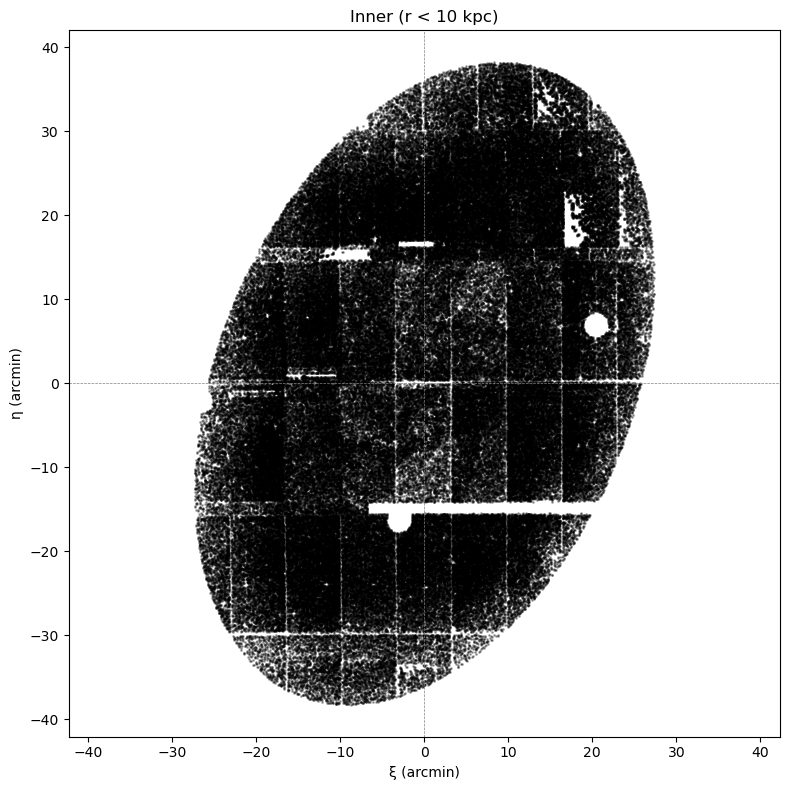

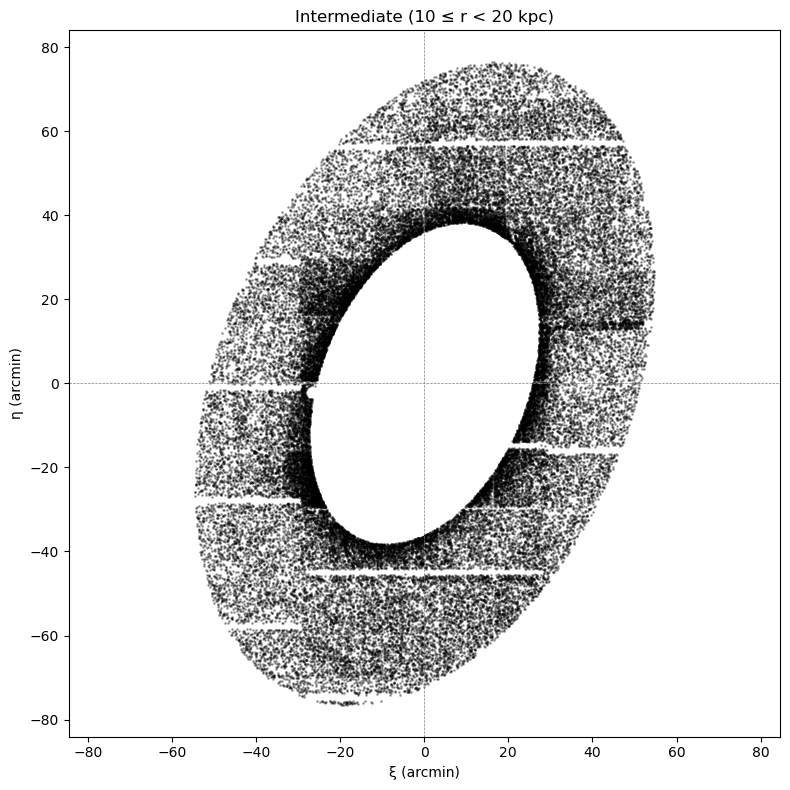

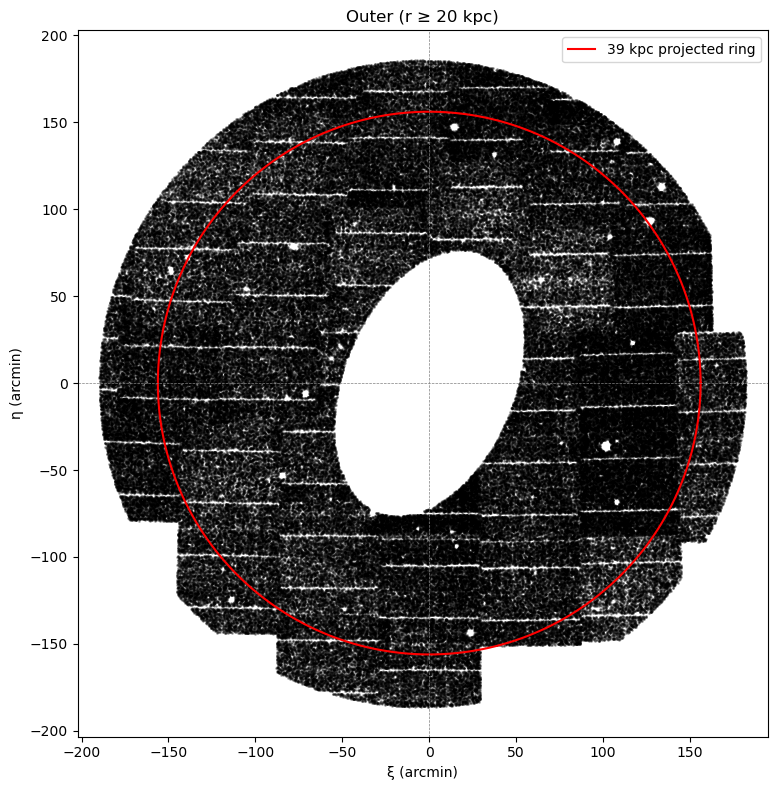

In [24]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

# === Compute ξ/η coordinates ===
center = SkyCoord(ra=23.4621 * u.deg, dec=30.6602 * u.deg)
coords = SkyCoord(ra=panda['RA_DEG'].values * u.deg, dec=panda['DEC_DEG'].values * u.deg)
offset = coords.transform_to(center.skyoffset_frame())
panda['xi'] = offset.lon.arcminute
panda['eta'] = offset.lat.arcminute

# === Parameters ===
distance_kpc = 859
ring_kpc_projected = 39  # projected (not deprojected!) radius

# === Radial masks using deprojected radius (kept for population definition) ===
radial_masks = {
    'Inner (r < 10 kpc)': panda['r_deproj_kpc'] < 10,
    'Intermediate (10 ≤ r < 20 kpc)': (panda['r_deproj_kpc'] >= 10) & (panda['r_deproj_kpc'] < 20),
    'Outer (r ≥ 20 kpc)': panda['r_deproj_kpc'] >= 20
}

# === Plot ξ/η with circular ring on outer ===
for title, mask in radial_masks.items():
    plt.figure(figsize=(8, 8))
    plt.scatter(panda.loc[mask, 'xi'], panda.loc[mask, 'eta'], s=1, c='black', alpha=0.3)

    if 'Outer' in title:
        # Compute projected radius in arcminutes
        ring_rad = ring_kpc_projected / distance_kpc  # radians
        ring_arcmin = ring_rad * (180 / np.pi) * 60   # arcmin

        # Parametrize circle
        phi = np.linspace(0, 2 * np.pi, 500)
        xi_circle = ring_arcmin * np.cos(phi)
        eta_circle = ring_arcmin * np.sin(phi)

        plt.plot(xi_circle, eta_circle, color='red', linewidth=1.5, label=f'{ring_kpc_projected} kpc projected ring')
        plt.legend()

    plt.xlabel('ξ (arcmin)')
    plt.ylabel('η (arcmin)')
    plt.title(f'{title}')
    plt.axhline(0, color='gray', lw=0.5, linestyle='--')
    plt.axvline(0, color='gray', lw=0.5, linestyle='--')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

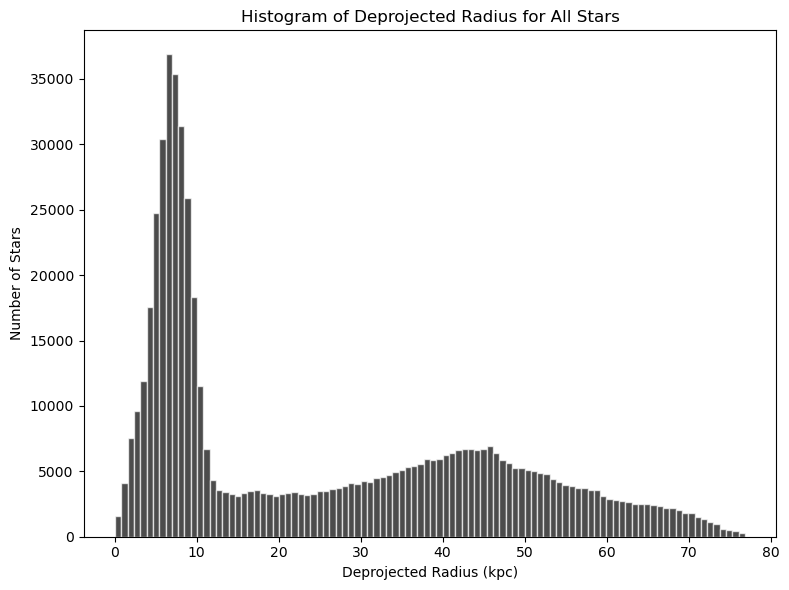

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(panda['r_deproj_kpc'], bins=100, color='black', edgecolor='white', alpha=0.7)
plt.xlabel('Deprojected Radius (kpc)')
plt.ylabel('Number of Stars')
plt.title('Histogram of Deprojected Radius for All Stars')
plt.tight_layout()
plt.show()

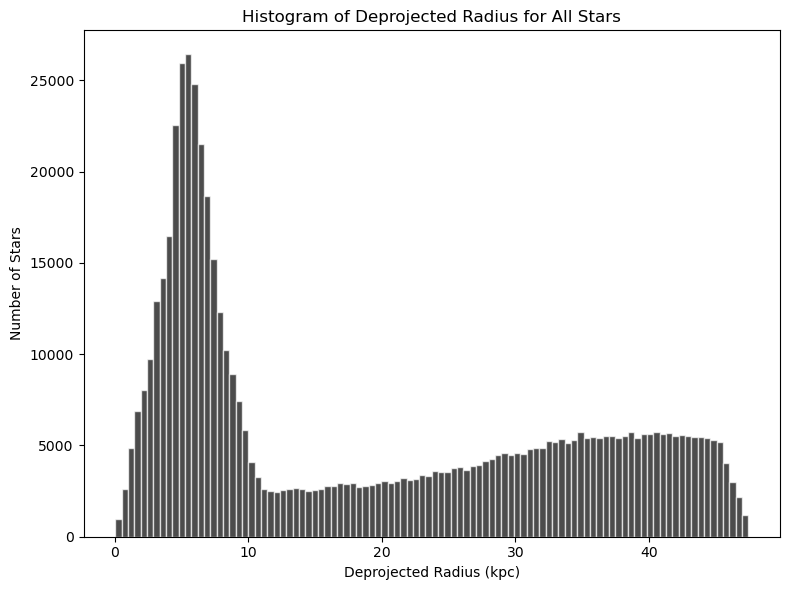

In [23]:
plt.figure(figsize=(8, 6))
plt.hist(panda['projected_radius_kpc'], bins=100, color='black', edgecolor='white', alpha=0.7)
plt.xlabel('Deprojected Radius (kpc)')
plt.ylabel('Number of Stars')
plt.title('Histogram of Deprojected Radius for All Stars')
plt.tight_layout()
plt.show()

In [ ]:
colors = {'young': 'blue', 'int': 'orange', 'old': 'red', 'young_unconfirmed': 'green'}

# === CMD plots in radial bins ===
bins = np.arange(0, 35, 2.5)

for r_min in bins:
    subset = panda[panda['r_deproj_kpc'] > r_min].copy()
    plt.figure(figsize=(12, 8))
    plt.scatter(subset['color'], subset['mag'], s=1, alpha=0.3, c='k', edgecolors='none')

    for group in ['old', 'int', 'young', 'young_unconfirmed']:
        stars = df[(df['age_group'] == group) & (df['r_deproj_kpc'] > r_min)]
        plt.scatter(
            stars['color'], stars['mag'],
            s=20, alpha=0.8, color=colors[group],
            label=group, edgecolors='k', linewidths=0.3
        )

    plt.gca().invert_yaxis()
    plt.xlabel('g - i')
    plt.ylabel('i magnitude')
    plt.xlim(-2.5, 5)
    plt.ylim(24, 16)
    plt.title(f'CMD: r > {r_min:.1f} kpc')
    plt.legend()
    plt.tight_layout()
    plt.show()

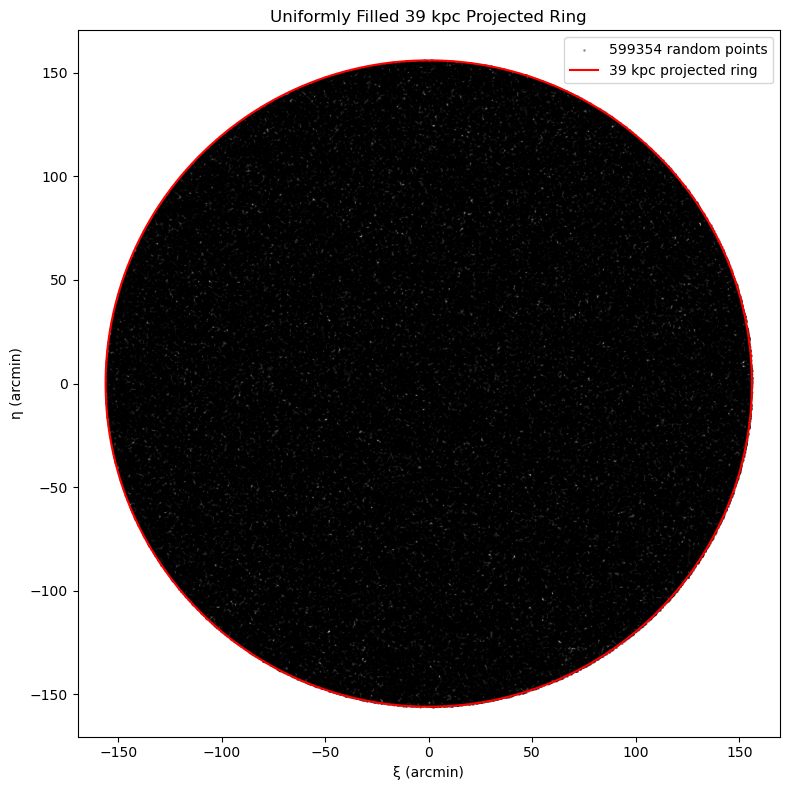

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# === Setup ===
distance_kpc = 859
ring_kpc_projected = 39

# Convert 39 kpc to arcmin
ring_rad = ring_kpc_projected / distance_kpc  # radians
ring_arcmin = ring_rad * (180 / np.pi) * 60   # arcminutes

# Number of points = number of stars in panda
n_points = len(panda)

# === Generate random points uniformly inside the circle ===
r = ring_arcmin * np.sqrt(np.random.rand(n_points))  # sqrt ensures uniform density
theta = 2 * np.pi * np.random.rand(n_points)

xi_rand = r * np.cos(theta)
eta_rand = r * np.sin(theta)

# === Plot ===
plt.figure(figsize=(8, 8))
plt.scatter(xi_rand, eta_rand, s=1, alpha=0.3, color='black', label=f'{n_points} random points')

# Circle outline
phi = np.linspace(0, 2 * np.pi, 500)
xi_circle = ring_arcmin * np.cos(phi)
eta_circle = ring_arcmin * np.sin(phi)
plt.plot(xi_circle, eta_circle, color='red', linewidth=1.5, label='39 kpc projected ring')

plt.xlabel('ξ (arcmin)')
plt.ylabel('η (arcmin)')
plt.title('Uniformly Filled 39 kpc Projected Ring')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()
